# 03 · Extension: SAMME (from scratch)
Report section: *Extension method(s)* + part of *Results*. SAMME on the leakage-safe split, mean +/- std over 3 seeds, plus the convergence curve and the betting-market benchmark. Results saved to `report/results_extension.csv`.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data.pipeline import build_dataset
from src.data.odds import method_market, market_benchmark
from src.extension import SAMMEClassifier
from src.metrics import (accuracy, precision_recall_f1, log_loss,
                         collapse_winner, collapse_method, summarize_over_seeds)
from src.plotting import plot_staged_accuracy, save_fig

## 1. Implementation
SAMME lives in `src/extension/samme.py` (validated vs sklearn in `tests/unit/test_samme.py`). The stump caps candidate splits at ~64 quantile thresholds for speed.

## 2. SAMME, seed-averaged (D2 run)
200 stumps per seed (~2 min each after the threshold cap). Scored on the original-corner test, collapsed to winner/method like the baselines.

In [2]:
SEEDS = [0, 1, 2]
acc6, winacc, metacc, ll = ({}, {}, {}, {})
for k in (acc6, winacc, metacc, ll): k['SAMME'] = []
keep = {}
for s in SEEDS:
    ds = build_dataset(seed=s)
    Xtr, ytr, Xte, yte = ds.X_train.values, ds.y_train.values, ds.X_test.values, ds.y_test.values
    m = SAMMEClassifier(n_estimators=200).fit(Xtr, ytr)
    proba = m.predict_proba(Xte); pred = m.classes_[proba.argmax(1)]
    acc6['SAMME'].append(accuracy(yte, pred))
    winacc['SAMME'].append(accuracy(collapse_winner(yte), collapse_winner(pred)))
    metacc['SAMME'].append(accuracy(collapse_method(yte), collapse_method(pred)))
    ll['SAMME'].append(log_loss(yte, proba, classes=m.classes_))
    if s == 0: keep = dict(model=m, ds=ds, Xte=Xte, yte=yte)
a_m, a_s = summarize_over_seeds(acc6['SAMME']); w_m, w_s = summarize_over_seeds(winacc['SAMME'])
me_m, _ = summarize_over_seeds(metacc['SAMME']); l_m, _ = summarize_over_seeds(ll['SAMME'])
res = pd.DataFrame([{'model': 'SAMME', 'acc6_mean': a_m, 'acc6_std': a_s, 'winner_mean': w_m,
                     'winner_std': w_s, 'method_mean': me_m, 'logloss_mean': l_m}]).set_index('model').round(3)
res.to_csv('../report/results_extension.csv'); res

,acc6_mean,acc6_std,winner_mean,winner_std,method_mean,logloss_mean
model,,,,,,
SAMME,0.349,0.012,0.633,0.016,0.515,1.663


## 3. Hyperparameter analysis (E2)
**(Milica, issue #14)** convergence curve below as a worked example; k and PCA sweeps remain.

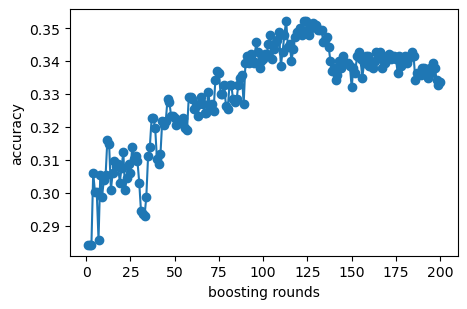

peak at round 113: acc=0.352 (200 may slightly overfit)


In [3]:
scores = keep['model'].staged_score(keep['Xte'], keep['yte'])
plot_staged_accuracy(scores); save_fig('hyperparam_samme'); plt.show()
print(f'peak at round {int(np.argmax(scores))+1}: acc={max(scores):.3f} (200 may slightly overfit)')

## 3b. Confusion matrix (6-class)
Where SAMME's errors fall, on the seed-0 split. Predictions concentrate on the common decision classes (Red-DEC, Blue-DEC); knockouts and especially submissions are recovered far less often. (The best baseline's matrix, LDA, is in `02_baselines.ipynb`.)

In [ ]:
from src.metrics import confusion_matrix
from src.plotting import plot_confusion_matrix
# reuse the seed-0 model kept above (same split the baseline confusion matrix uses)
M, classes = confusion_matrix(keep['yte'], keep['model'].predict(keep['Xte']), classes=keep['model'].classes_)
plot_confusion_matrix(M, classes, normalize=True); plt.title('SAMME (row-normalized)')
save_fig('confusion_matrix_samme'); plt.show()

## 4. Odds benchmark (D4)
SAMME vs the de-vigged per-method market by log-loss / Brier, on test fights with full market coverage.

In [4]:
ds0 = keep['ds']; m = keep['model']
mkt = method_market(ds0.df, classes=m.classes_).loc[ds0.test_index]
res = market_benchmark(ds0.y_test.values, m.predict_proba(ds0.X_test.values), mkt.values, m.classes_)
print(f'covered fights: {res["n_fights"]}')
print(f'log-loss  SAMME={res["log_loss"]["model"]:.3f}  market={res["log_loss"]["market"]:.3f}')
print(f'Brier     SAMME={res["brier"]["model"]:.3f}  market={res["brier"]["market"]:.3f}')
pd.DataFrame([{'metric':'log_loss','SAMME':res['log_loss']['model'],'market':res['log_loss']['market']},
              {'metric':'brier','SAMME':res['brier']['model'],'market':res['brier']['market']}]).to_csv('../report/results_market.csv', index=False)

covered fights: 1099
log-loss  SAMME=1.665  market=1.551
Brier     SAMME=0.793  market=0.749
